# Adoption of AI Among Students

This analysis evaluates patterns of AI usage, adoption behavior, satisfaction, and continued usage across student groups.

Key focus:
- Adoption behavior
- Usage intensity
- Satisfaction trends
- Retention patterns


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

df = pd.read_csv('assets/ai_assistant_usage_student_life.csv')

df.head()

,SessionID,StudentLevel,Discipline,SessionDate,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating
0,SESSION00001,Undergraduate,Computer Science,2024-11-03,31.20,11,Studying,2,Assignment Completed,True,1.0
1,SESSION00002,Undergraduate,Psychology,2024-08-25,13.09,6,Studying,3,Assignment Completed,True,2.0
2,SESSION00003,Undergraduate,Business,2025-01-12,19.22,5,Coding,3,Assignment Completed,True,3.3
3,SESSION00004,Undergraduate,Computer Science,2025-05-06,3.70,1,Coding,3,Assignment Completed,True,3.5
4,SESSION00005,Undergraduate,Psychology,2025-03-18,28.12,9,Writing,3,Assignment Completed,True,2.9


## Data Overview

Initial inspection of structure, variable types, and summary statistics.

In [2]:
print('Shape:', df.shape)
df.info()
df.describe()
df.describe(include='object')

Shape: (10000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SessionID           10000 non-null  object 
 1   StudentLevel        10000 non-null  object 
 2   Discipline          10000 non-null  object 
 3   SessionDate         10000 non-null  object 
 4   SessionLengthMin    10000 non-null  float64
 5   TotalPrompts        10000 non-null  int64  
 6   TaskType            10000 non-null  object 
 7   AI_AssistanceLevel  10000 non-null  int64  
 8   FinalOutcome        10000 non-null  object 
 9   UsedAgain           10000 non-null  bool   
 10  SatisfactionRating  10000 non-null  float64
dtypes: bool(1), float64(2), int64(2), object(6)
memory usage: 791.1+ KB


,SessionID,StudentLevel,Discipline,SessionDate,TaskType,FinalOutcome
count,10000,10000,10000,10000,10000,10000
unique,10000,3,7,366,6,4
top,SESSION00001,Undergraduate,Biology,2025-04-03,Writing,Assignment Completed
freq,1,5978,1458,41,3101,4768


## Data Cleaning and Preparation

In [3]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle missing values
for col in df.select_dtypes(include=['number']):
   df[col] = df[col].fillna(df[col].median())

# Convert date
df['SessionDate'] = pd.to_datetime(df['SessionDate'], errors='coerce')

## Feature Engineering

In [4]:
# Adoption indicator
df['HighUsage'] = df['TotalPrompts'] > df['TotalPrompts'].median()

# Efficiency metric
df['Efficiency'] = df['TotalPrompts'] / df['SessionLengthMin']

# Monthly usage
df['Month'] = df['SessionDate'].dt.month

## Distribution Analysis

/home/mukul/Main/Projects/Ai_usage/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/mukul/Main/Projects/Ai_usage/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/mukul/Main/Projects/Ai_usage/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


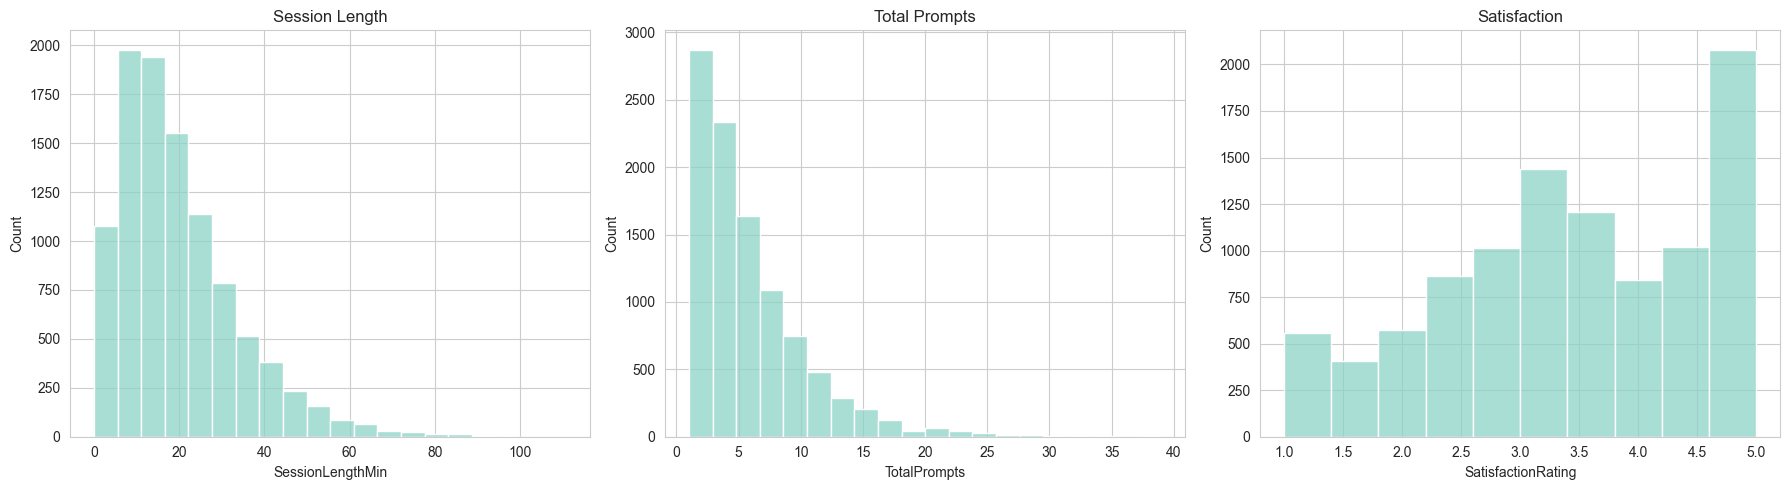

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(df['SessionLengthMin'], bins=20, ax=axes[0])
axes[0].set_title('Session Length')

sns.histplot(df['TotalPrompts'], bins=20, ax=axes[1])
axes[1].set_title('Total Prompts')

sns.histplot(df['SatisfactionRating'], bins=10, ax=axes[2])
axes[2].set_title('Satisfaction')

plt.tight_layout()
plt.show()

## Adoption Patterns

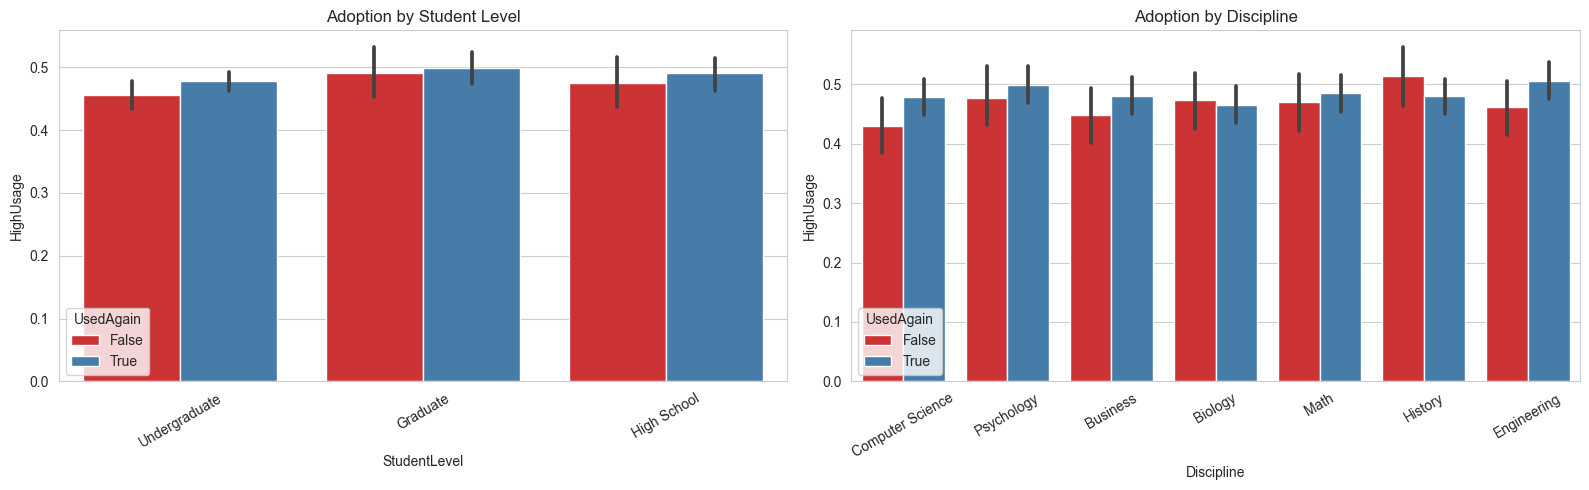

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16,5))

sns.barplot(x='StudentLevel', y='HighUsage', hue='UsedAgain', palette='Set1', data=df, ax=axes[0])
axes[0].set_title('Adoption by Student Level')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(x='Discipline', y='HighUsage', hue='UsedAgain', palette='Set1', data=df, ax=axes[1])
axes[1].set_title('Adoption by Discipline')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## Usage and Behavior

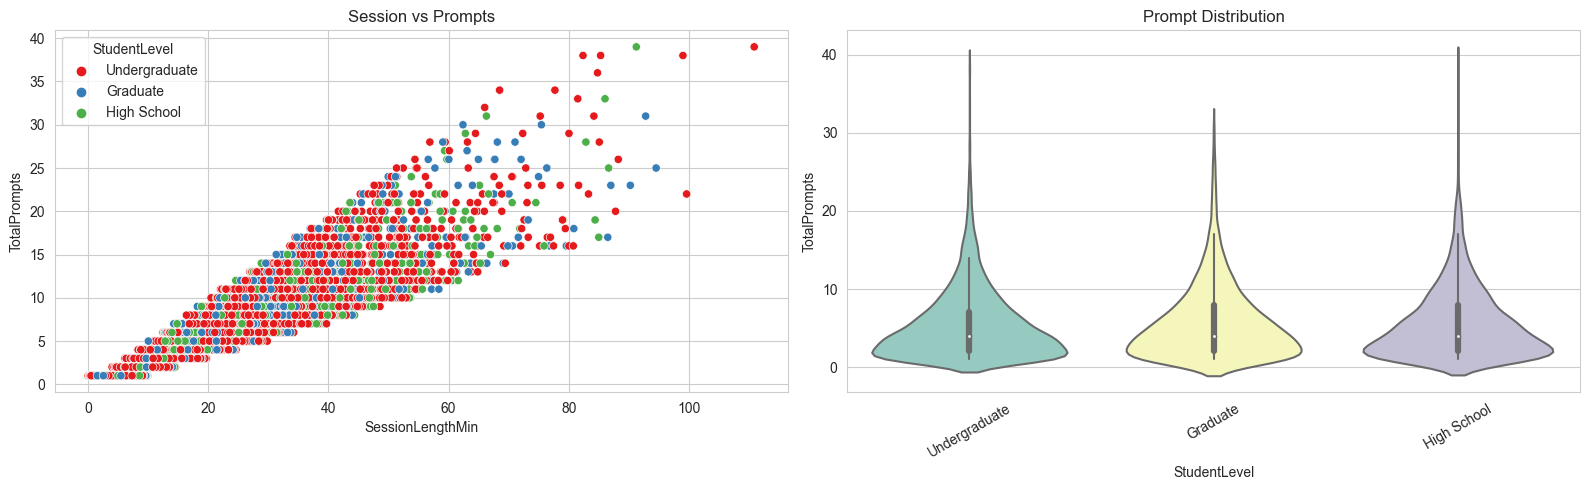

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16,5))

sns.scatterplot(x='SessionLengthMin', y='TotalPrompts', hue='StudentLevel', palette='Set1', data=df, ax=axes[0])
axes[0].set_title('Session vs Prompts')

sns.violinplot(x='StudentLevel', y='TotalPrompts', data=df, ax=axes[1])
axes[1].set_title('Prompt Distribution')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## Satisfaction Analysis

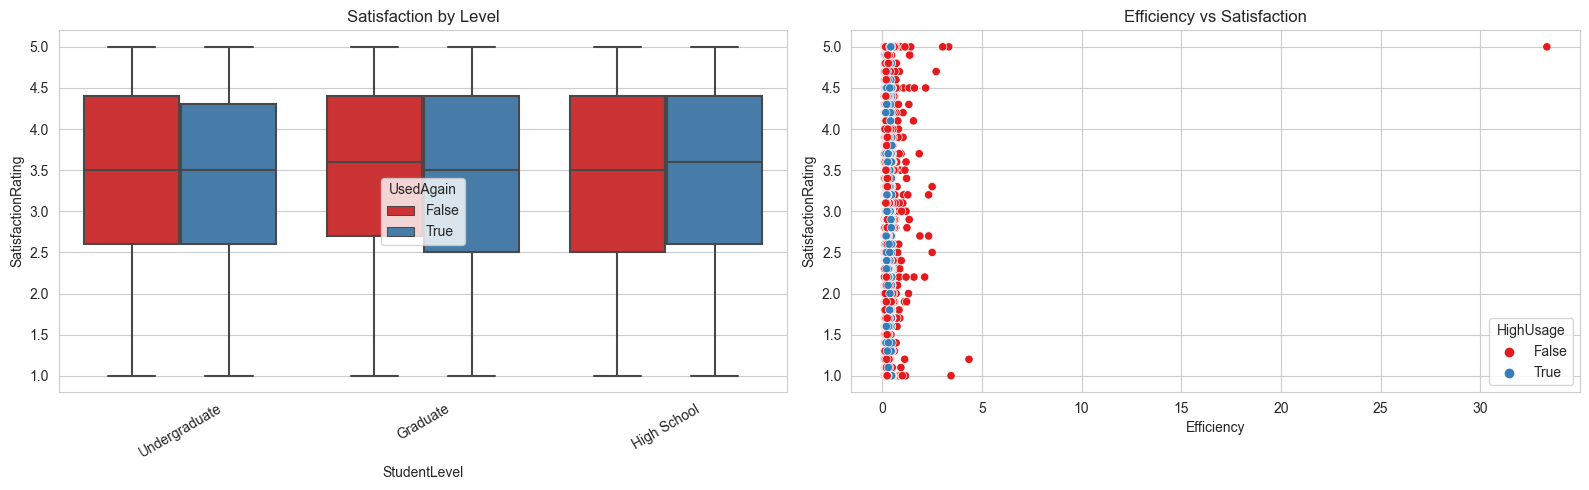

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16,5))

sns.boxplot(x='StudentLevel', y='SatisfactionRating', hue='UsedAgain', palette='Set1', data=df, ax=axes[0])
axes[0].set_title('Satisfaction by Level')
axes[0].tick_params(axis='x', rotation=30)

sns.scatterplot(x='Efficiency', y='SatisfactionRating', hue='HighUsage', palette='Set1', data=df, ax=axes[1])
axes[1].set_title('Efficiency vs Satisfaction')

plt.tight_layout()
plt.show()

## Time Trend

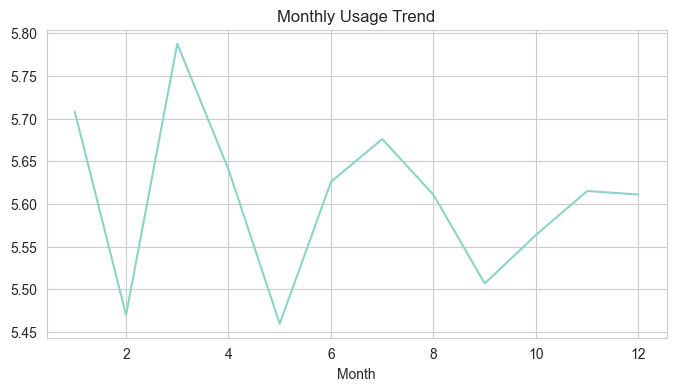

In [9]:
df.groupby('Month')['TotalPrompts'].mean().plot(figsize=(8,4))
plt.title('Monthly Usage Trend')
plt.show()

## Correlation

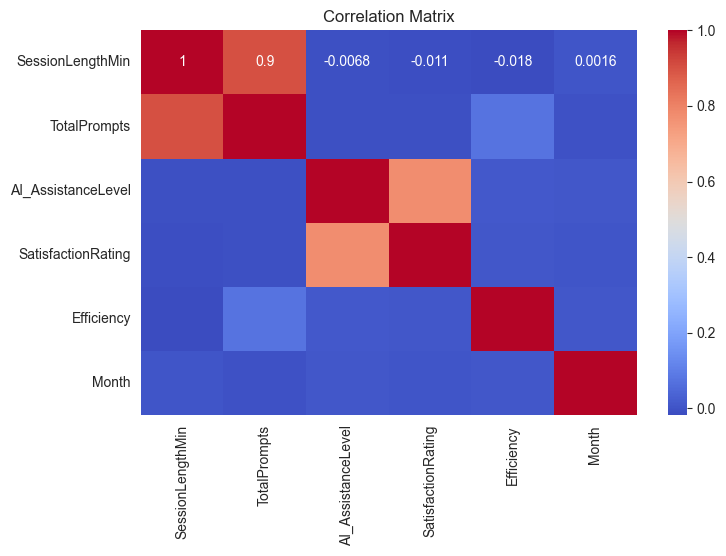

In [10]:
plt.figure(figsize=(8,5))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()



## Key Insights

- Students who use AI more tend to spend more time per session
- Higher usage is generally linked with higher satisfaction
- Some student groups use AI more frequently than others
- Students who use AI more are more likely to use it again
- Usage patterns differ across disciplines


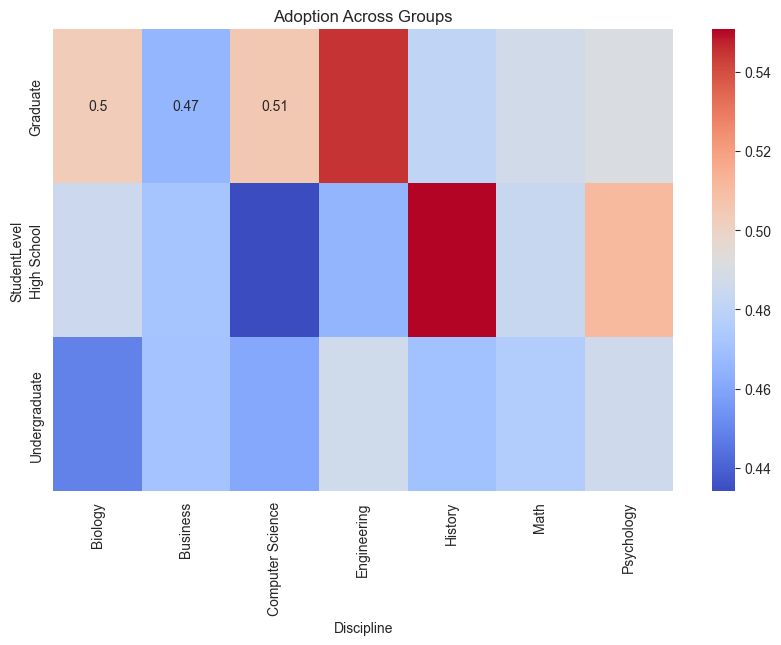

In [11]:
pivot = df.pivot_table(values='HighUsage', index='StudentLevel', columns='Discipline', aggfunc='mean')

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title('Adoption Across Groups')
plt.show()

## Logistic Regression

A simple classification model is used to predict whether a student will continue using AI tools based on their usage and behavior.

### Insight
Students with higher usage and satisfaction are more likely to continue using AI, showing a strong link between engagement and adoption.

Accuracy: 0.6925

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       615
           1       0.69      1.00      0.82      1385

    accuracy                           0.69      2000
   macro avg       0.35      0.50      0.41      2000
weighted avg       0.48      0.69      0.57      2000



/home/mukul/Main/Projects/Ai_usage/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mukul/Main/Projects/Ai_usage/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mukul/Main/Projects/Ai_usage/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

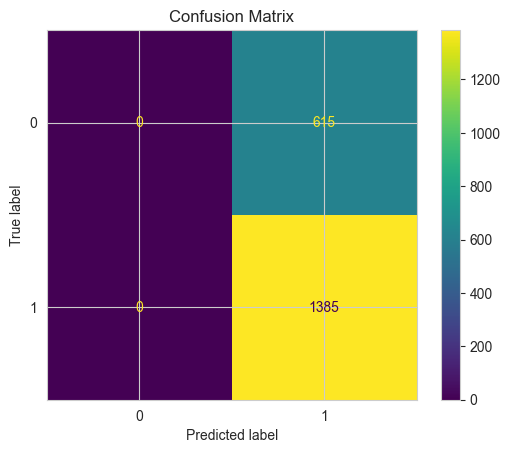

In [12]:
# Logistic Regression Model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Copy dataset
df_ml = df.copy()

# Encode categorical columns
for col in df_ml.select_dtypes(include='object'):
    df_ml[col] = LabelEncoder().fit_transform(df_ml[col].astype(str))

# Convert boolean to int
df_ml['UsedAgain'] = df_ml['UsedAgain'].astype(int)
df_ml['HighUsage'] = df_ml['HighUsage'].astype(int)

# Drop unnecessary columns
X = df_ml.drop(['UsedAgain', 'SessionID', 'SessionDate'], axis=1)
y = df_ml['UsedAgain']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title("Confusion Matrix")
plt.show()

In [23]:
import pandas as pd

# Read the CSV file into a DataFrame
dataset = pd.read_csv(r"./assets/ai_assistant_usage_student_life.csv")



In [24]:
dataset


,SessionID,StudentLevel,Discipline,SessionDate,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating
0,SESSION00001,Undergraduate,Computer Science,2024-11-03,31.20,11,Studying,2,Assignment Completed,True,1.0
1,SESSION00002,Undergraduate,Psychology,2024-08-25,13.09,6,Studying,3,Assignment Completed,True,2.0
2,SESSION00003,Undergraduate,Business,2025-01-12,19.22,5,Coding,3,Assignment Completed,True,3.3
3,SESSION00004,Undergraduate,Computer Science,2025-05-06,3.70,1,Coding,3,Assignment Completed,True,3.5
4,SESSION00005,Undergraduate,Psychology,2025-03-18,28.12,9,Writing,3,Assignment Completed,True,2.9
...,...,...,...,...,...,...,...,...,...,...,...
9995,SESSION09996,Undergraduate,Psychology,2024-07-20,28.41,5,Studying,3,Assignment Completed,True,4.2
9996,SESSION09997,High School,Business,2024-11-11,13.98,6,Writing,5,Assignment Completed,True,5.0
9997,SESSION09998,Undergraduate,Biology,2024-09-11,10.78,2,Studying,3,Idea Drafted,True,3.5
9998,SESSION09999,Undergraduate,Business,2024-10-27,30.88,7,Writing,3,Assignment Completed,False,4.3


In [26]:
# Save the DataFrame to an Excel file
dataset.to_excel(r"./assets/ai_assistant_usage_student_life.xlsx", index=False)